In [1]:
import torch
from matplotlib import pyplot as plt
import random
from flow_matching.latent.training_cae import detransform
from flow_matching.supervised.odes_sdes import CFGVectorFieldODE
from flow_matching.supervised.alphas_betas import LinearAlpha, LinearBeta
from flow_matching.supervised.prob_paths import GaussianConditionalProbabilityPath
from flow_matching.whar.sampler import WHARSampler
from flow_matching.whar.models.dit import DiT
from flow_matching.whar.models.unet import WHARUnet
from flow_matching.whar.flow_trainer import FlowTrainer
from flow_matching.supervised.simulators import RK4Simulator

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [3]:
sampler = WHARSampler()

2025-09-17 17:43:41,191 - whar-datasets - INFO - Running DownloadingStep
2025-09-17 17:43:41,192 - whar-datasets - INFO - Checking hash for DownloadingStep
2025-09-17 17:43:41,192 - whar-datasets - INFO - Hash is up to date
2025-09-17 17:43:41,193 - whar-datasets - INFO - Running ParsingStep
2025-09-17 17:43:41,193 - whar-datasets - INFO - Checking hash for ParsingStep
2025-09-17 17:43:41,194 - whar-datasets - INFO - Hash is up to date
2025-09-17 17:43:41,194 - whar-datasets - INFO - Running WindowingStep
2025-09-17 17:43:41,194 - whar-datasets - INFO - Checking hash for WindowingStep
2025-09-17 17:43:41,195 - whar-datasets - INFO - Hash is up to date
2025-09-17 17:43:41,195 - whar-datasets - INFO - Loading windowing
2025-09-17 17:43:41,218 - whar-datasets - INFO - activity_ids from 0 to 5
2025-09-17 17:43:41,219 - whar-datasets - INFO - subject_ids from 0 to 29
2025-09-17 17:43:41,221 - whar-datasets - INFO - train: 8002 | test: 1497
2025-09-17 17:43:41,221 - whar-datasets - INFO - Ru

num_samples: 7201
shape: [18, 32, 32]
num_classes: 6


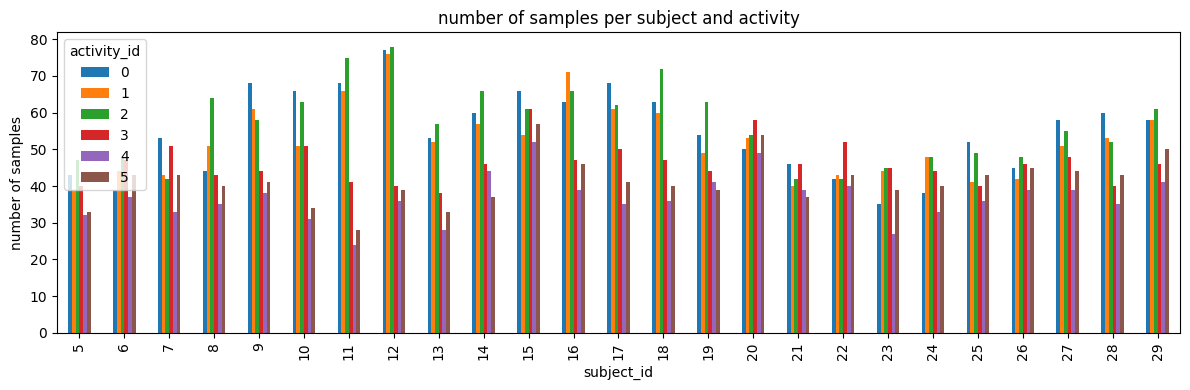

In [4]:
print(f"num_samples: {len(sampler.train_indices)}")

shape = sampler.get_shape()
num_channels = shape[1]
print(f"shape: {shape}")

num_classes = sampler.get_num_classes(sampler.train_indices)
print(f"num_classes: {num_classes}")

sampler.sampler.plot_indices_statistics(sampler.train_indices)

In [5]:
path = GaussianConditionalProbabilityPath(
    p_data=sampler,
    p_simple_shape=shape,
    alpha=LinearAlpha(),
    beta=LinearBeta(),
).to(device)

# vf = DiT(
#     channels=shape[0],
#     patch_size=2,
#     embed_dim=128,
#     time_dim=128,
#     num_heads=2,
#     num_blocks=2,
#     num_classes=num_classes,
# ).to(device)

vf = WHARUnet(
    in_channels=shape[0],
    channels=[32, 64, 128],
    num_blocks=2,
    emb_dim=128,
    num_classes=num_classes,
)

trainer = FlowTrainer(
    path=path,
    model=vf,
    eta=(1 / num_classes),
    null_class=num_classes,
    num_classes=num_classes,
    num_samples=150,
    num_timesteps=30,
)

In [6]:
trainer.train(
    num_epochs=10,
    steps_per_epoch=2000,
    device=device,
    lr=3e-4,
    batch_size=32,
)

2025-09-17 17:43:45,035 - flow-matching - INFO - Training model with size: 7.285 MiB
100%|██████████| 29/29 [00:16<00:00,  1.79it/s]
2025-09-17 17:48:51,131 - flow-matching - INFO - ['kid: 0.003317', 'precision: 0.995556', 'recall: 0.000000', 'f1: 0.000000']
Epoch 1/10:  36%|███▌      | 714/2000 [01:11<02:09,  9.96it/s, loss=0.128294]


KeyboardInterrupt: 

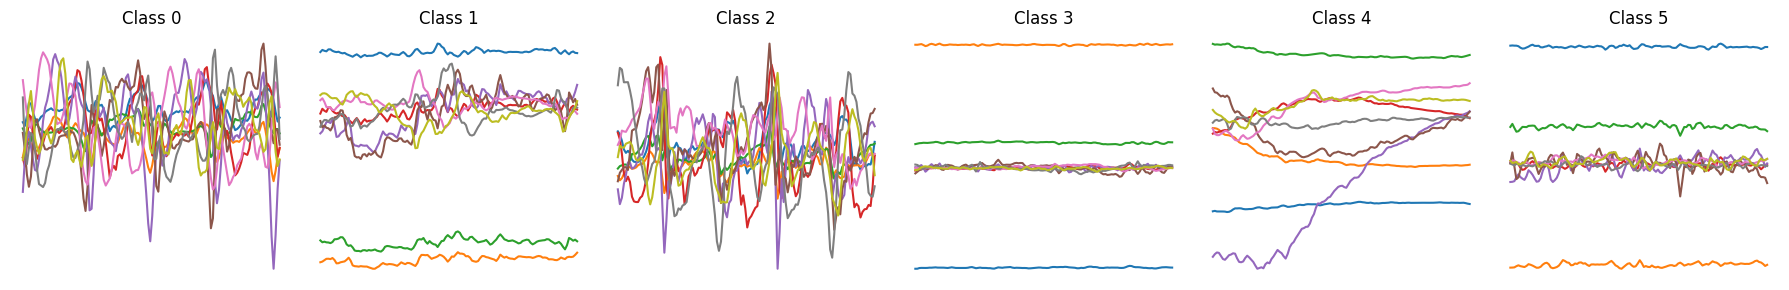

100%|██████████| 99/99 [00:10<00:00,  9.54it/s]


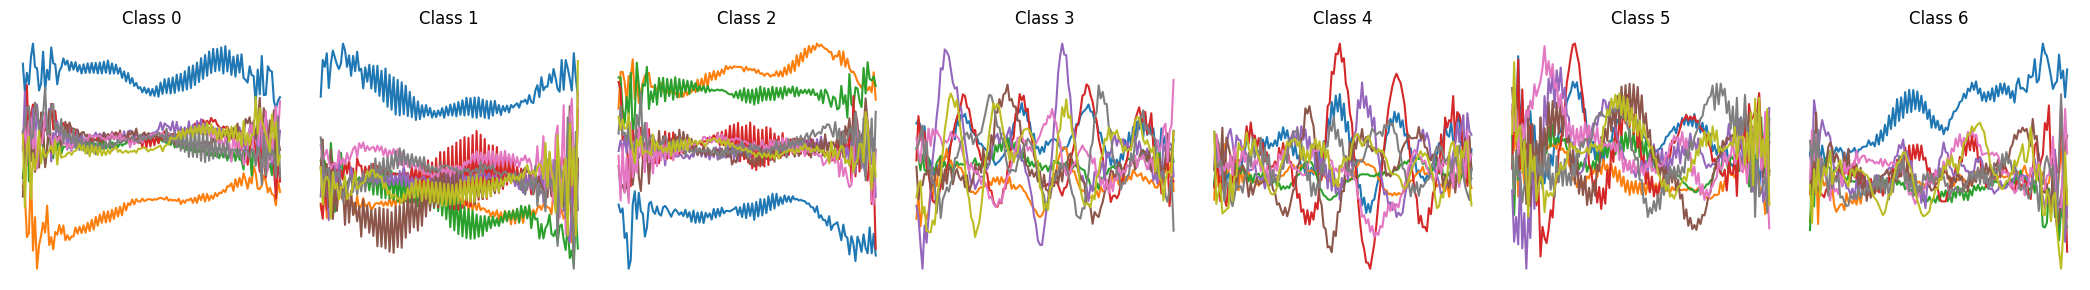

In [7]:
num_samples = 6
seed = random.randint(0, 1000)

samples = {}
for i in range(0, num_samples):
    x1, y = sampler.sample_train(1, class_label=i, seed=seed)
    samples[i] = detransform(x1.squeeze(0))

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(samples),
    figsize=(3 * len(samples), 3),
)

for key, val in samples.items():
    ax = axes[key]
    ax.plot(val)
    ax.set_title(f"Class {key}")
    ax.axis("off")

plt.tight_layout()
plt.show()

y = torch.arange(num_classes + 1).to(device)
num_samples = y.shape[0]
num_timesteps = 100
w = 2.0

x0, _ = path.p_simple.sample(num_samples)
x0 = x0.to(device)

ode = CFGVectorFieldODE(vf, guidance_scale=w, null_class=num_classes)
simulator = RK4Simulator(ode)

ts = (
    torch.linspace(0, 1, num_timesteps)
    .view(1, -1, 1, 1, 1)
    .expand(num_samples, -1, 1, 1, 1)
    .to(device)
)

x1 = simulator.simulate(x0, ts, y)

samples = {}
for i in range(0, num_samples):
    samples[i] = detransform(x1[i].squeeze(0)).detach().cpu()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(samples),
    figsize=(3 * len(samples), 3),
)

for key, val in samples.items():
    ax = axes[key]
    ax.plot(val)
    ax.set_title(f"Class {key}")
    ax.axis("off")

plt.tight_layout()
plt.show()